# Docs Examples

In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
from diffinytrace.basis_functions.bspline import basis_2d
import torch


In [ ]:
cube = dit.integrators.Cube([[0, 1], [0, 1]])
points, weights = cube.sample([10, 10], method="midpoint")
volume = cube.get_volume()
all_in_bounds = cube.in_bounds(points)

print("Sampled points:\n", points)
print("Integration weights:\n", weights)
print("Cube volume:", volume)
print("All points in bounds:", all_in_bounds)

In [ ]:
disc = dit.integrators.Disc(1.0)
points, weights = disc.sample(2**4, method="sobol_pow2")
volume = disc.get_volume()
all_in_bounds = disc.in_bounds(points)
print("Sampled points:", points)
print("Integration weights:", weights)
print("Disc area:", volume)
print("All points in bounds:", all_in_bounds)


In [ ]:
callback_fun = lambda:None
callback_fun()

In [ ]:
import diffinytrace.config as config
config.set_tolerance(1e-8)
config.set_show_iteration_count(True)
config.restore_default_settings()

In [ ]:

import torch
import matplotlib.pyplot as plt
from diffinytrace.basis_functions import bspline
U = torch.tensor([0., 0.2, 0.4, 0.6, 0.8, 1])
n = 3
k = 3  # This is order 3
print(U[0], U[-1])
xis = torch.linspace(0, 1, 100)
xN = bspline.basis_1d(xis, U,k ,n,[0.,1.])
num_points = xN.shape[0]
tmp = xN.reshape(num_points, -1, 1) * xN.reshape(num_points, 1, -1)
for yin in xN.T:
    plt.plot(xis, yin)
plt.gca().set_aspect('equal')


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
n = 4
control_points = torch.randn((n, 2))  # Random control points
k = 4  # Quadratic B-spline
U = torch.tensor([0.0] * (k - 1) + list(np.linspace(0, 1.0, n + k - 2 * (k - 1))) + [1.0] * (k - 1))
U = U.float()
print(U.shape[0] - k == n, n >= k)
for m in range(100):
    U_new, new_control_points = bspline.insert_knot1D_single(U, k, torch.rand((1)), control_points)
    print("new_control_points", new_control_points)
    print("control_points", control_points)
    xis = torch.linspace(0, 1, 1000)
    xN1 = bspline.basis_1d(xis,U, k, 3, [0,1.])
    out1 = xN1 @ control_points
    xN2 = bspline.basis_1d(xis,U_new, k, 4, [0,1.])
    out2 = xN2 @ new_control_points
    plt.plot(out1[:, 0], out1[:, 1], linewidth=5.0)
    plt.plot(out2[:, 0], out2[:, 1], "--")
    torch.mean((out1 - out2) ** 2)

In [ ]:
import torch
from diffinytrace.basis_functions import bspline
n_x, n_y = 4, 4
control_points = torch.randn((n_x, n_y, 2))
k_x, k_y = 3, 3
U_x = torch.linspace(0, 1, n_x + k_x)
U_y = torch.linspace(0, 1, n_y + k_y)
points = torch.rand((100, 2))
surface = bspline.surface_2d(points, [U_x, U_y], [k_x, k_y], [n_x, n_y], (0.0, 1.0), (0.0, 1.0), control_points)
surface

In [ ]:
import torch
import diffinytrace as dit

aperture_half = 30.0
aperture_radius = aperture_half
lens_thickness = 8.0
material = dit.materials["NBK7"]
transform = dit.transforms.Identity()

# degree [p, q] and control net size [n_u, n_v] (example values)
bspline = dit.Bspline(aperture_half, [3, 3], [8, 8])
plane = dit.Plane()

with torch.no_grad():
    bspline.coeff.data = torch.randn_like(bspline.coeff.data) * 3.0

lens = dit.Lens(transform, lens_thickness, bspline, plane,
                       material, aperture_radius)

dit.plotting.system3D.plot(lens, zticks=[0, 5])

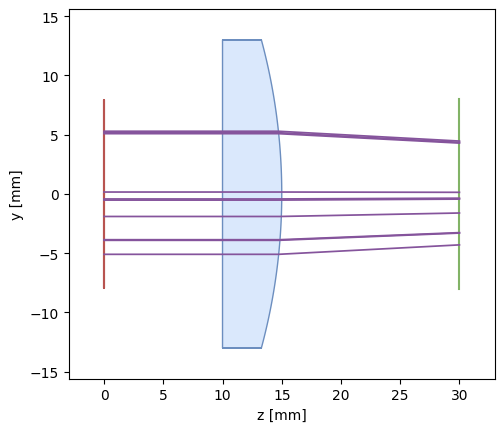

In [9]:
import diffinytrace as dit
import torch
NBK7 = dit.materials["NBK7"]

wave_len = 1.024
light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
source = dit.source.CollimatedMonochromatic(light_transform,8.0,wave_len)

plane_surface = dit.Plane()
surface2 = dit.Aspheric(-1/50.)
transf1 = dit.transforms.Distance(10.0,parent_transform=source)
lens1 = dit.Lens(transf1,5.,plane_surface,surface2,NBK7,13.0)
transf2 = dit.transforms.Distance(15.0,parent_transform=lens1)
detector = dit.Detector(transf2,plane_surface,8.0)
system = dit.SequentialOpticalSystem({"source":source, "lens":lens1, "detector":detector})
#dit.plotting.system3D.plot(system,resolution=10)
x,weights = source.sample(10)
O,D,wave_len,_,meta_data = system(x,["source","lens","detector"])
dit.plotting.system2D.plot(system,meta_data)